# EPLB Benchmark Analysis

Compare EPLB configurations across collected benchmark runs.

**Prerequisites:** Collect results with `just eplb-collect <run-name>` before running this notebook.
Each run lives in `benchmarks/eplb/<run-name>/` and contains `config.env`, `prometheus.json`, and `expert-load/` dumps.

See `benchmarks/eplb/README.md` for the full benchmark plan and execution steps.

In [108]:
%load_ext autoreload
%autoreload 2

from eplb_analysis import (
    load_run,
    load_runs,
    load_all_runs,
    list_runs,
    metrics_comparison_table,
    stage_metrics_table,
    balancedness_comparison_table,
    plot_latency_comparison,
    plot_throughput_comparison,
    plot_throughput_timeseries,
    plot_kv_cache_usage,
    plot_balancedness_comparison,
    plot_latency_timeseries,
    plot_phase_time_comparison,
    plot_phase_time_timeseries,
    plot_pareto_frontier,
    plot_throughput_vs_concurrency,
    plot_expert_load_all,
    plot_expert_load_heatmap,
    plot_rank_balance,
    plot_expert_popularity,
    plot_balancedness_over_time,
    plot_rank_balance_at_steps,
    plot_load_vs_latency,
    plot_per_rank_latency_heatmap,
    plot_per_rank_latency_spread,
    plot_per_rank_comparison,
    per_rank_stats_table,
    filter_runs,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Runs

In [109]:
print("Available runs:")
for name in list_runs():
    print(f"  {name}")

Available runs:


In [116]:
results_dir = "./very_high_load_new//"

selected = filter_runs(
    results_dir=results_dir, mode="pd", decode_pods=8, fork="study_v2", dataset="sharegpt"
)
runs = {name: load_run(name, results_dir) for name in selected.keys()}

print(f"Loaded {len(runs)} runs:")
for name, run in runs.items():
    expert_info = ""
    if run.expert_loads:
        n_snaps = sum(e.num_snapshots for e in run.expert_loads.values())
        expert_info = f", {n_snaps} expert snapshots"
    prom_info = "prometheus OK" if run.prometheus else "no prometheus"
    print(f"  {name}: {run.config} | {prom_info}{expert_info}")

Loaded 4 runs:
  pd-baseiline-sharegpt-v1: RunConfig('pd-baseiline-sharegpt-v1', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x8, prefill=2x1) | prometheus OK
  pd-baseiline-sharegpt-v2: RunConfig('pd-baseiline-sharegpt-v2', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x8, prefill=2x1) | prometheus OK
  pd-baseiline-sharegpt-v3: RunConfig('pd-baseiline-sharegpt-v3', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x8, prefill=2x1) | prometheus OK
  pd-baseiline-sharegpt-v4-dbo: RunConfig('pd-baseiline-sharegpt-v4-dbo', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x8, prefill=2x1) | prometheus OK


## 2. Pareto Frontier & Throughput

Headline answer: is EPLB worth it? Each point is one concurrency stage.
The Pareto frontier shows the tradeoff between system throughput and per-user output speed.

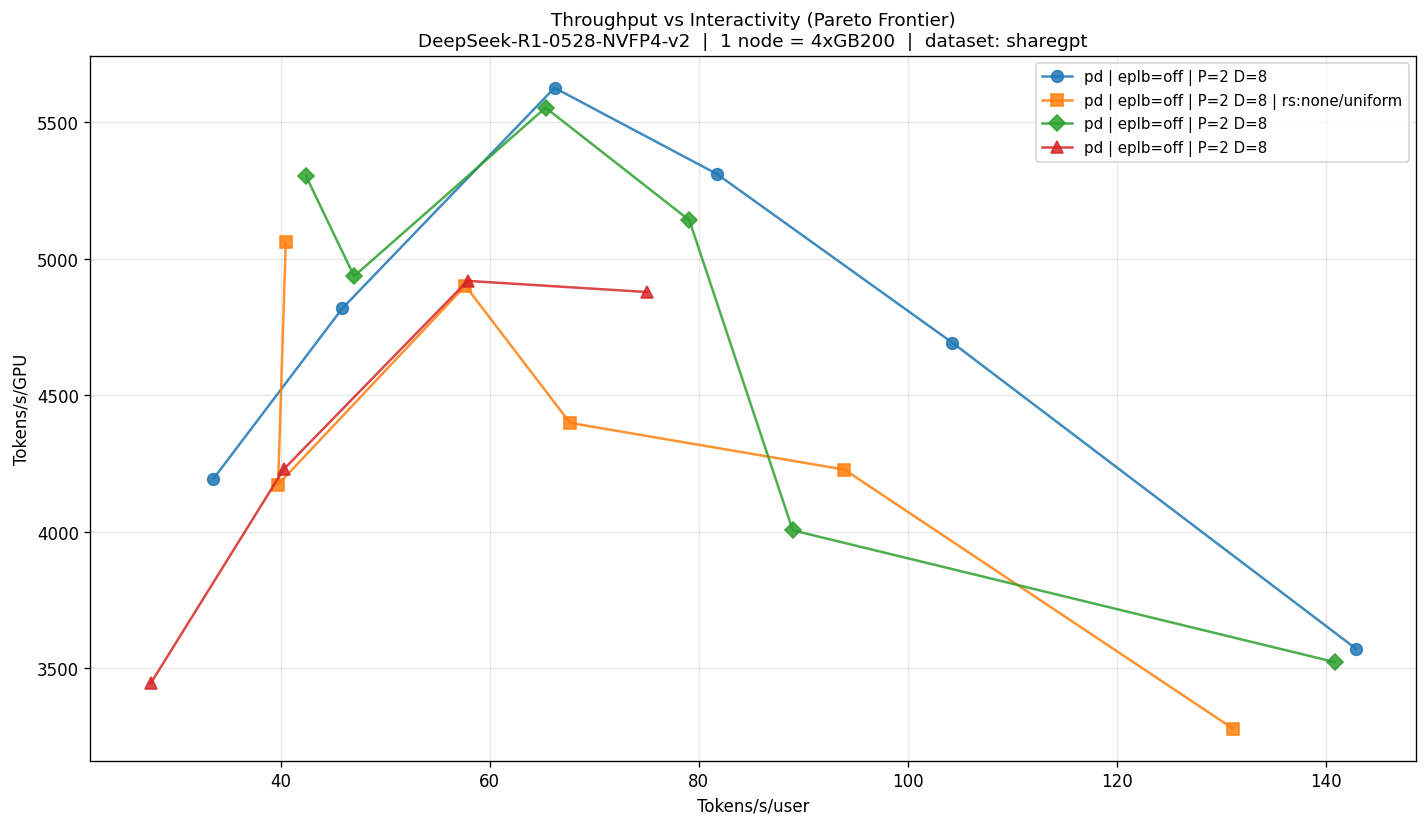

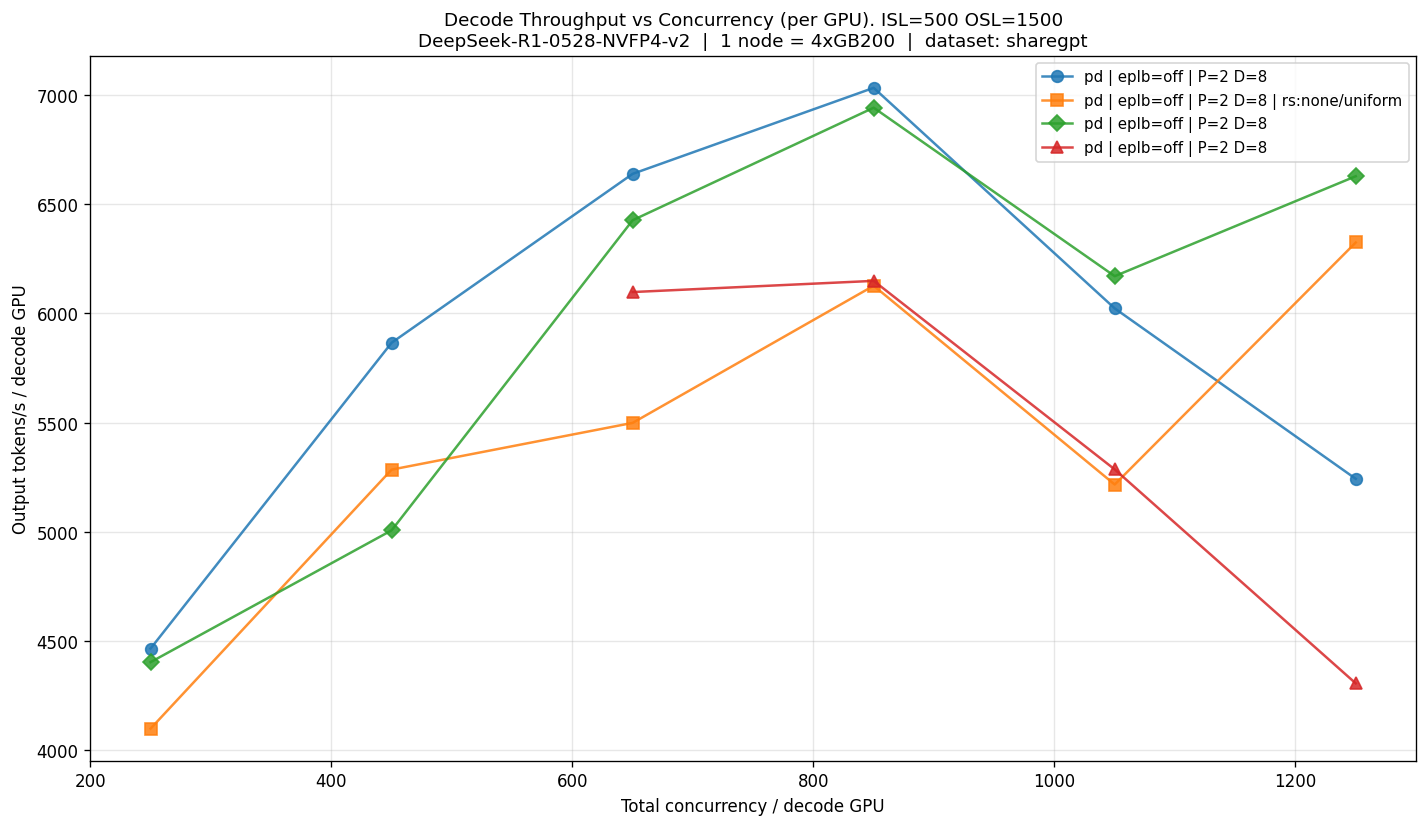

In [117]:
plot_pareto_frontier(runs)
plt.show()
plot_throughput_vs_concurrency(runs)
plt.show()

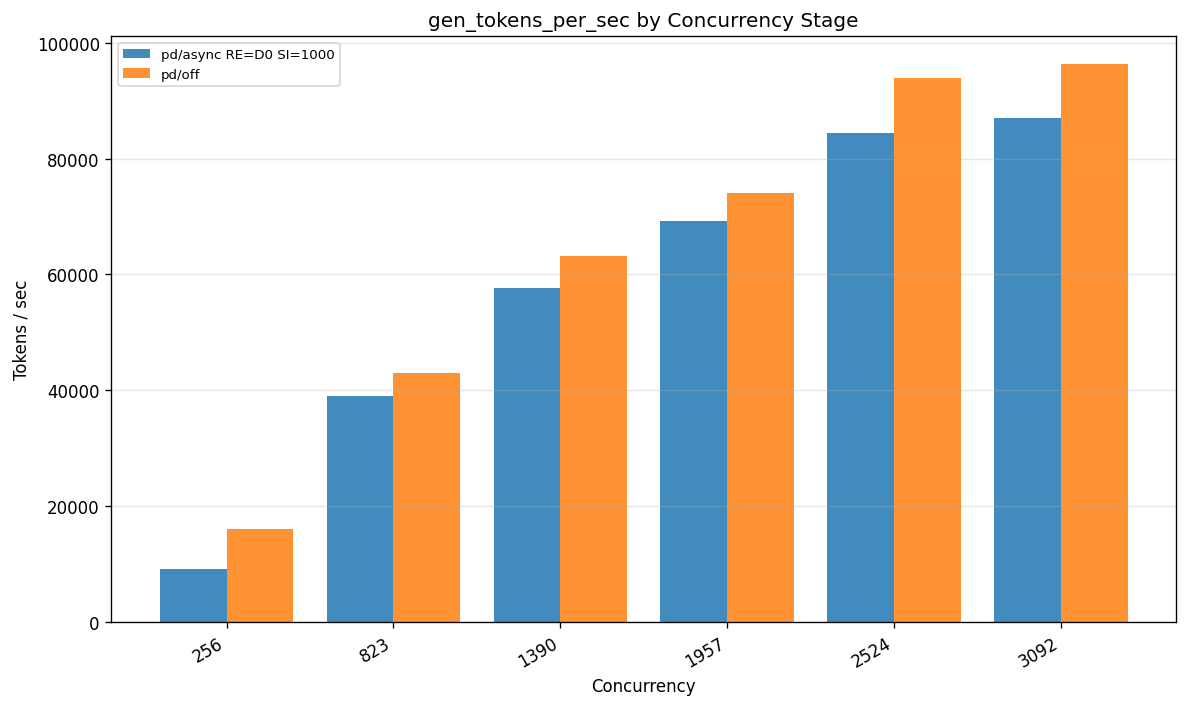

In [50]:
plot_throughput_comparison(runs)
plt.show()

## 3. Expert Load Balancedness

Did EPLB actually rebalance? Cross-run comparison and per-run deep dive.

### 3a. Cross-run balancedness comparison

In [ ]:
df_bal = balancedness_comparison_table(runs)
if not df_bal.empty:
    display(df_bal)
else:
    print("No expert load data available.")

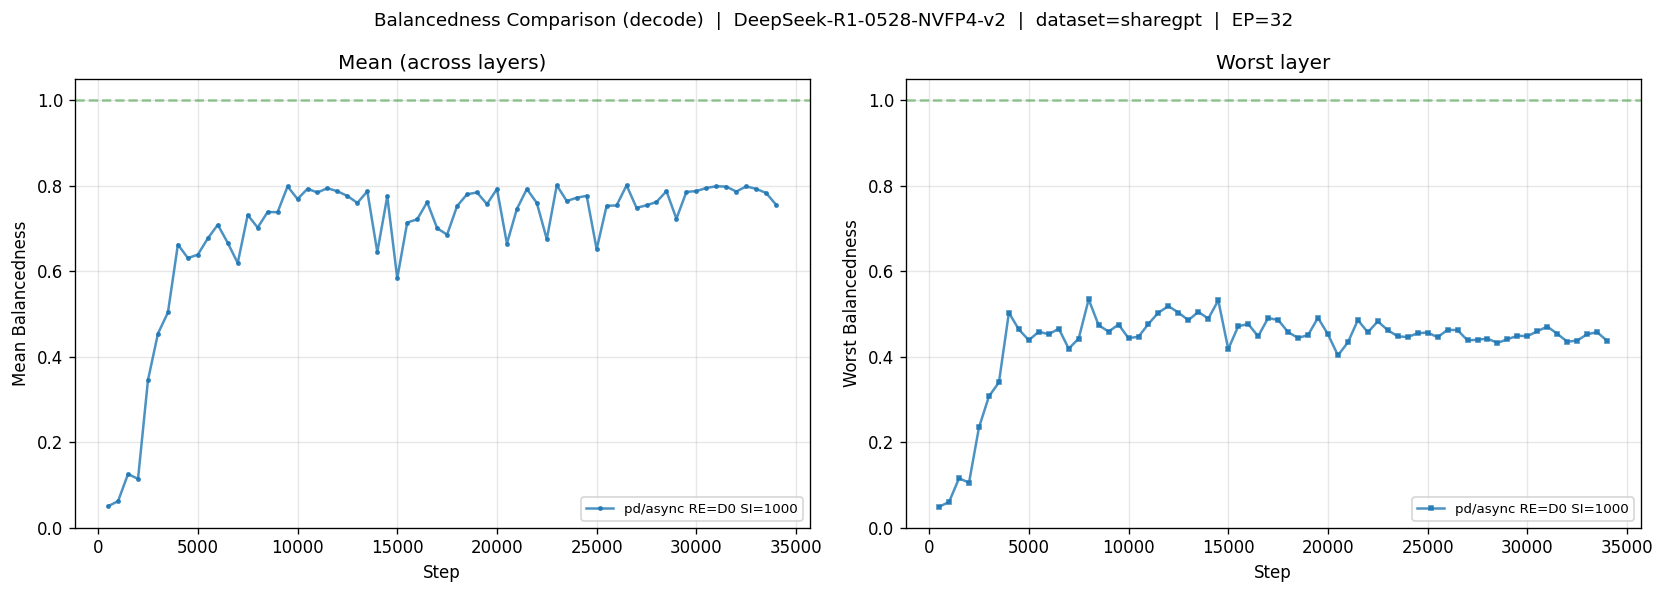

In [66]:
plot_balancedness_comparison(runs, max_step="auto", role="decode", show_heatmaps=False)
plt.show()

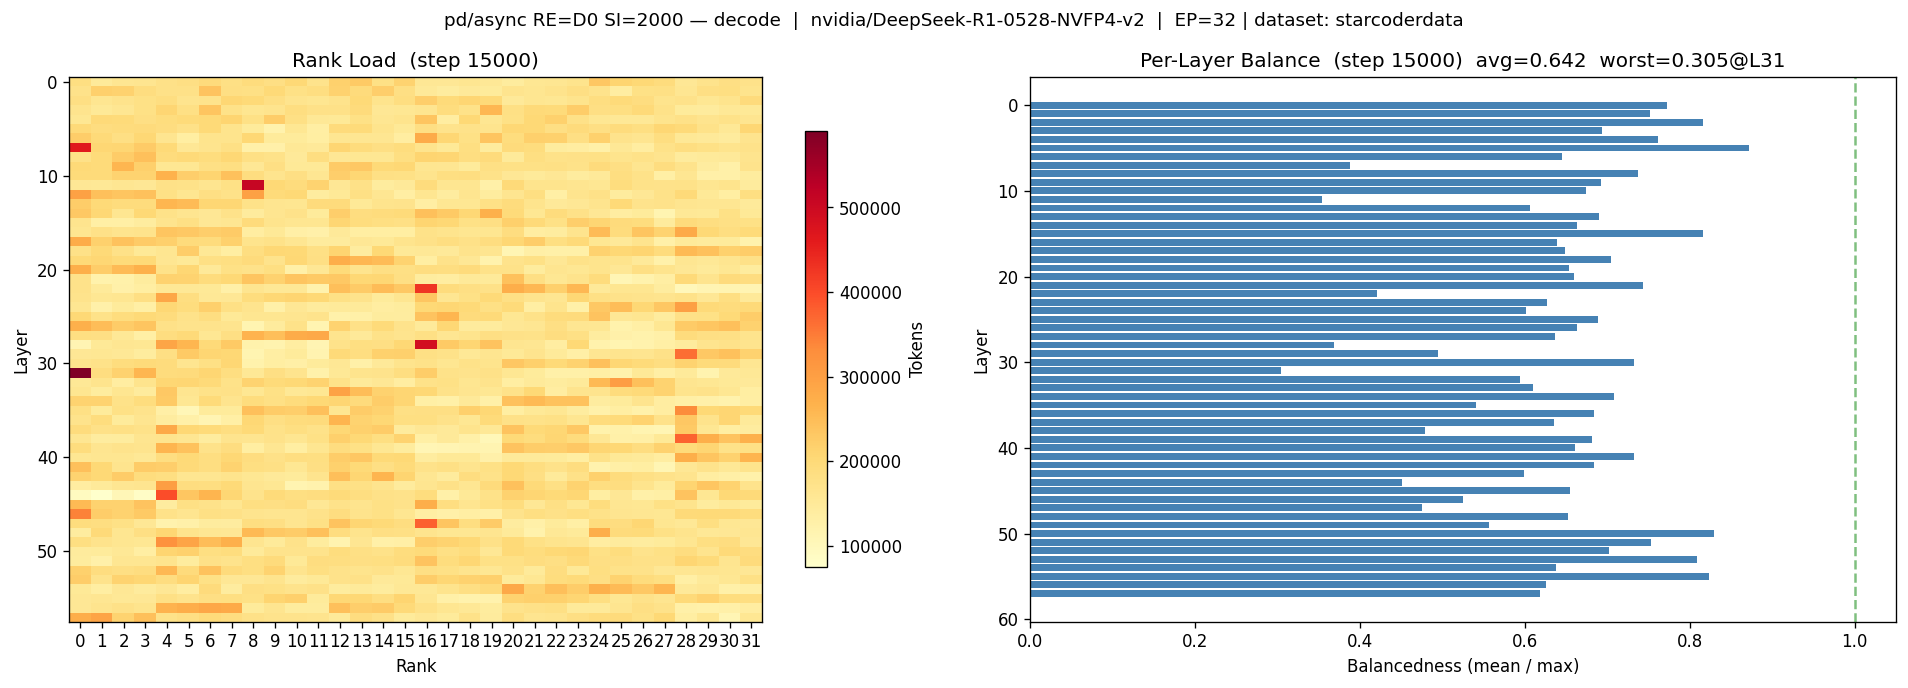

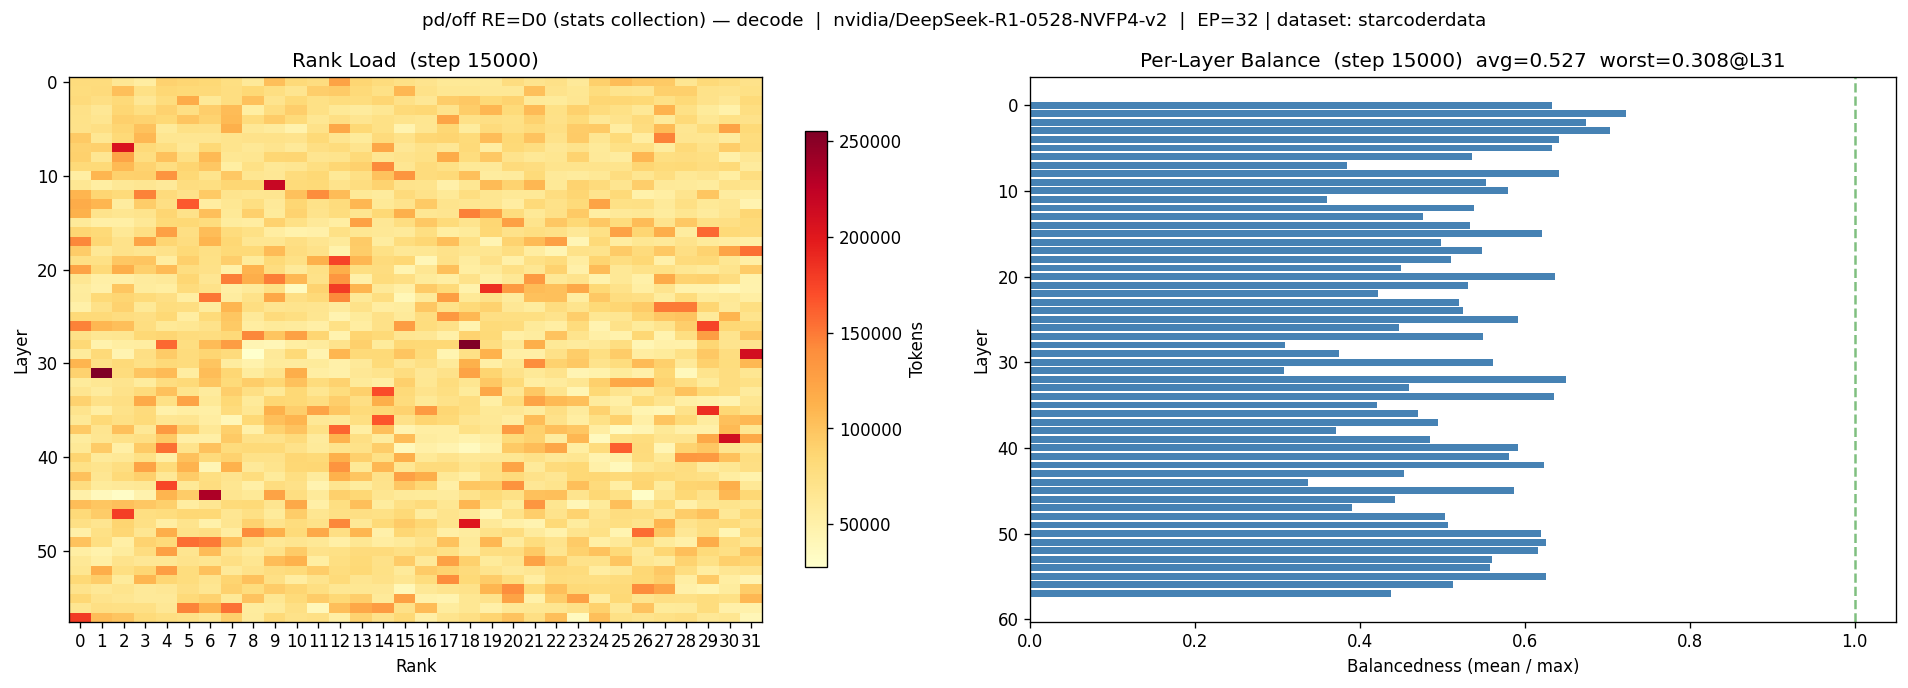

In [70]:
for run in runs.values():
    plot_rank_balance_at_steps(run, steps=[15000], role="decode")

### 3b. Per-run deep dive

In [ ]:
dive_run_name = list(runs.keys())[0]

if dive_run_name and runs[dive_run_name].expert_loads:
    dive_run = runs[dive_run_name]
    for model_key, expert_data in dive_run.expert_loads.items():
        print(f"\n=== {dive_run_name} / {model_key} ===")
        print(f"  Model: {expert_data.model}")
        print(f"  EP width: {expert_data.world_size}")
        print(f"  Layers: {expert_data.num_layers}, Physical experts: {expert_data.num_physical}")
        print(f"  Redundant: {expert_data.num_redundant}, Per rank: {expert_data.experts_per_rank}")
        print(f"  Snapshots: {expert_data.num_snapshots}")
        plot_expert_load_all(expert_data, title_suffix=f"  [{dive_run_name}]")
        plt.show()
else:
    print(f"No expert load data for {dive_run_name}")

## 4. KV Cache Usage

EPLB memory overhead: redundant experts consume memory that would otherwise hold KV cache.
Directly related to the balancedness tradeoff above.

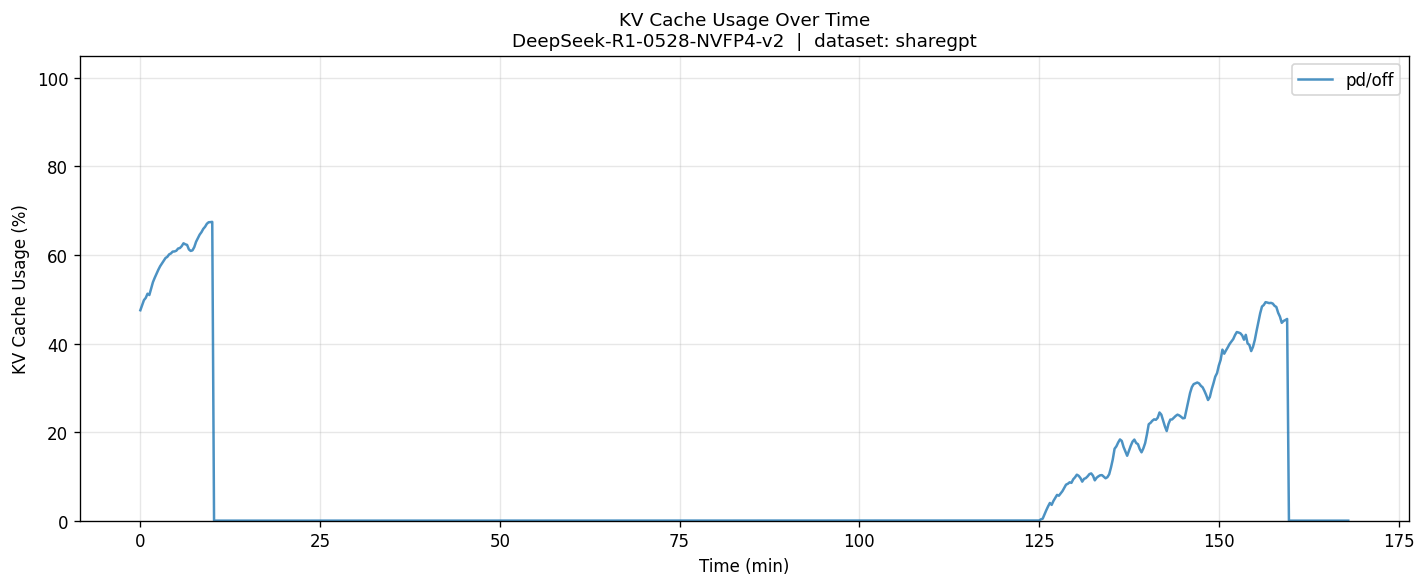

In [105]:
plot_kv_cache_usage(runs)
plt.show()

## 5. Per-Rank Latency Analysis

Compare how latency distributes across EP ranks at each concurrency stage.
If EPLB leaves certain ranks overloaded, per-rank metrics will show high spread (max/mean ratio >> 1).

In [36]:
df_rank = per_rank_stats_table(runs)
if not df_rank.empty:
    display(df_rank.round(2))
else:
    print("No per-rank range data found.")

mean       std  \
run                     concurrency metric                                    
pd/async RE=D32 SI=3000 256         itl_p50               236.660     0.240   
                                    itl_p99               299.030     0.020   
                                    decode_time_p50    144474.600 13079.850   
                                    decode_time_p99    463907.290  3697.360   
                                    gen_tokens_per_sec    274.190    19.560   
...                                                           ...       ...   
pd/off                  3092        itl_p50               252.550     0.130   
                                    itl_p99              1753.180    19.380   
                                    decode_time_p50    237001.040  5991.930   
                                    decode_time_p99    475100.900   153.480   
                                    gen_tokens_per_sec   2151.330    45.690   

                                                              min        max  \
run                     concurrency metric                                     
pd/async RE=D32 SI=3000 256         itl_p50               236.190    237.060   
                                    itl_p99               299.000    299.150   
                                    decode_time_p50    111923.080 168000.000   
                                    decode_time_p99    452914.290 469350.000   
                                    gen_tokens_per_sec    237.030    319.360   
...                                                           ...        ...   
pd/off                  3092        itl_p50               252.350    253.160   
                                    itl_p99              1705.200   1798.200   
                                    decode_time_p50    226133.330 256987.950   
                                    decode_time_p99    474801.250 475539.760   
                                    gen_tokens_per_sec   2022.970   2246.450   

                                                        max/mean  min_rank  \
run                     concurrency metric                                   
pd/async RE=D32 SI=3000 256         itl_p50                1.000        11   
                                    itl_p99                1.000        17   
                                    decode_time_p50        1.160         0   
                                    decode_time_p99        1.010         0   
                                    gen_tokens_per_sec     1.160         0   
...                                                          ...       ...   
pd/off                  3092        itl_p50                1.000        27   
                                    itl_p99                1.030        17   
                                    decode_time_p50        1.080         1   
                                    decode_time_p99        1.000         1   
                                    gen_tokens_per_sec     1.040         6   

                                                        max_rank  
run                     concurrency metric                        
pd/async RE=D32 SI=3000 256         itl_p50                   22  
                                    itl_p99                   29  
                                    decode_time_p50           29  
                                    decode_time_p99           20  
                                    gen_tokens_per_sec        30  
...                                                          ...  
pd/off                  3092        itl_p50                   17  
                                    itl_p99                    9  
                                    decode_time_p50           24  
                                    decode_time_p99           24  
                                    gen_tokens_per_sec        28  

[90 rows x 7 columns]

In [ ]:
plot_per_rank_latency_spread(runs, metric="itl_p99", title="Per-Rank ITL P99 — min/median/max across ranks by stage")
plt.show()
plot_per_rank_latency_spread(runs, metric="decode_time_p50", title="Per-Rank Decode Time P50 — spread by stage")
plt.show()

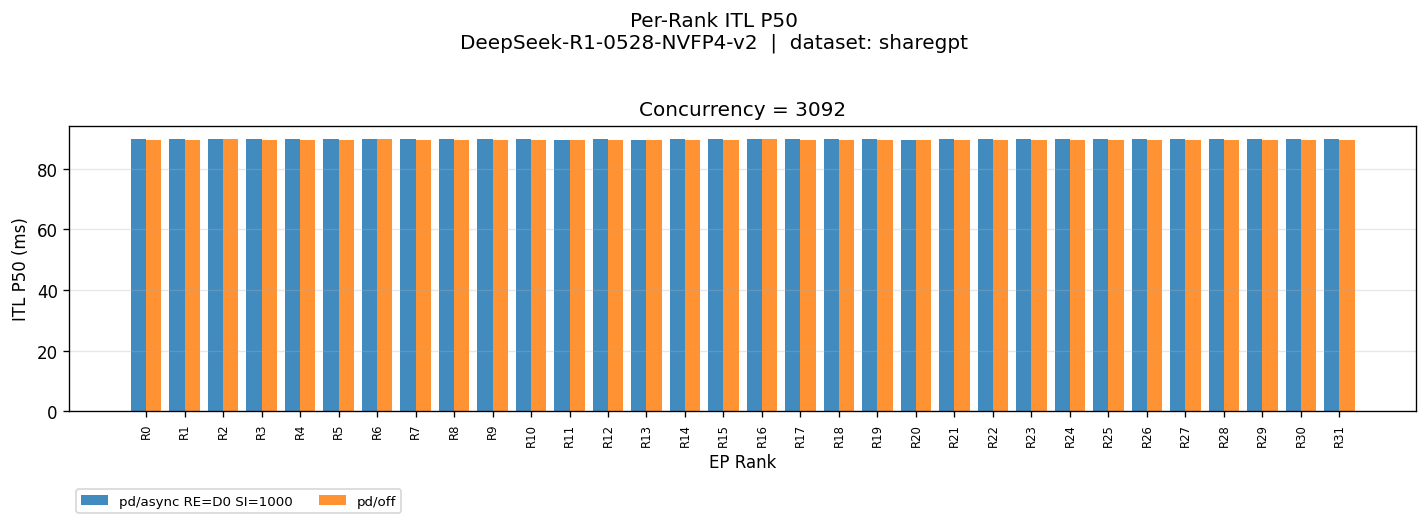

In [87]:
STAGE = 5
# runs_ = {name: value for name, value in runs.items() if "eplb" not in name}
plot_per_rank_comparison(runs, metric="itl_p50", title="Per-Rank ITL P50", stage=STAGE)
plt.show()
# plot_per_rank_comparison(runs, metric="itl_p99", title="Per-Rank ITL P99", stage=STAGE)
# plt.show()

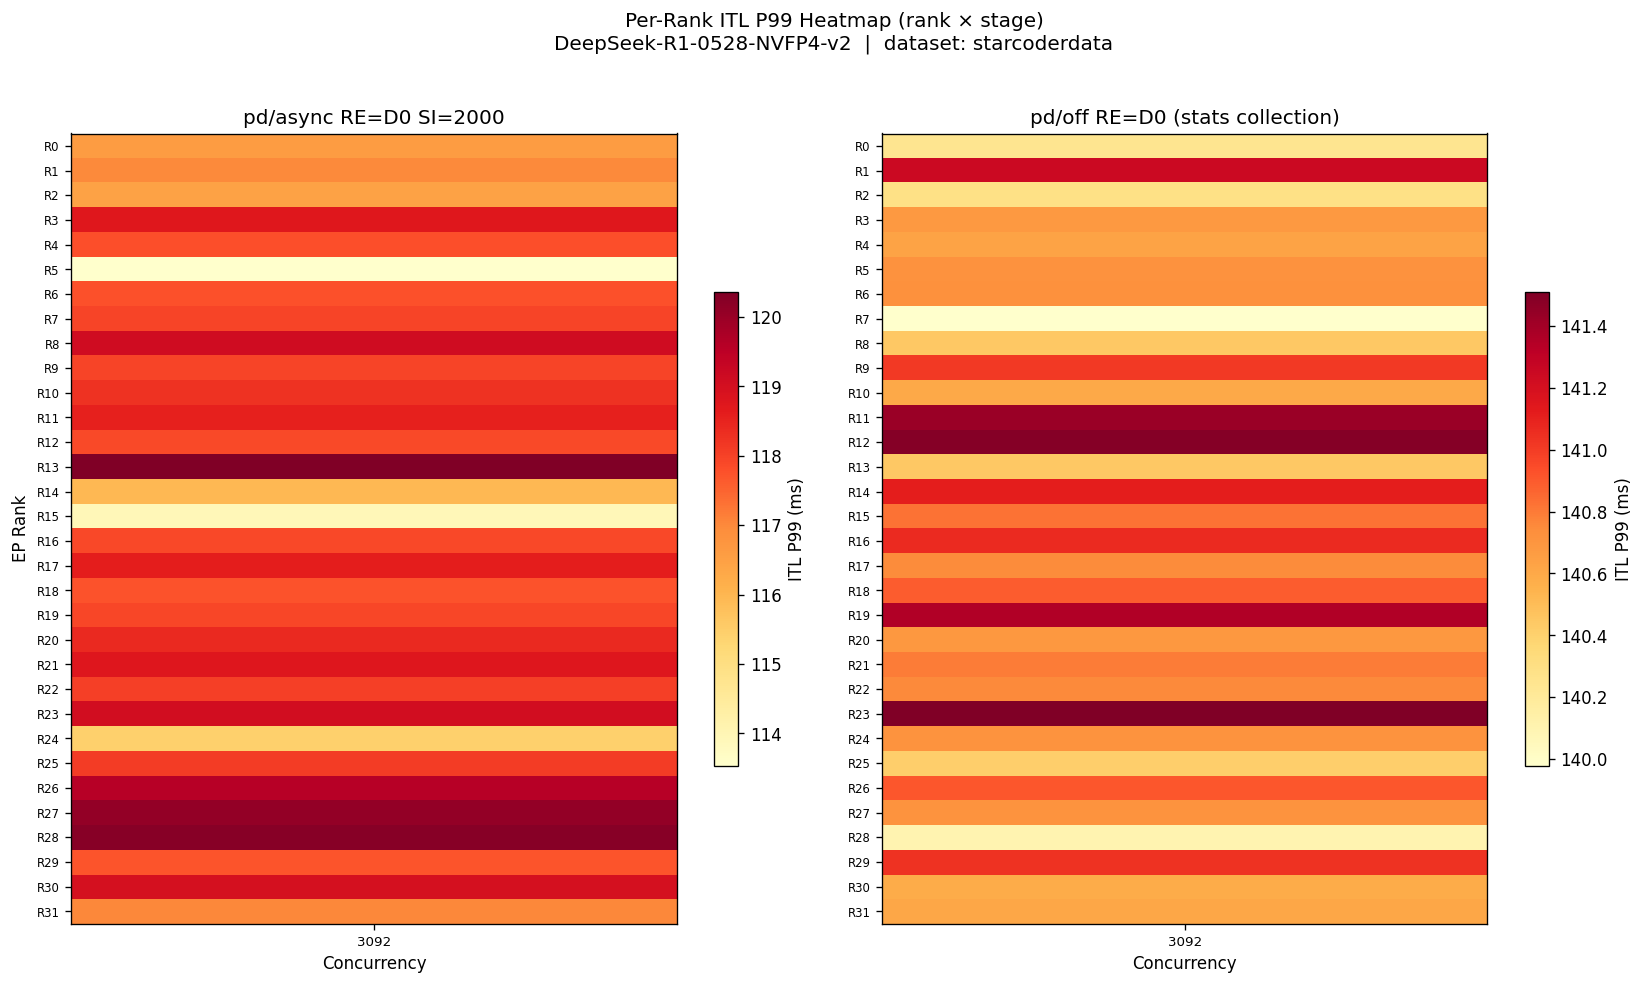

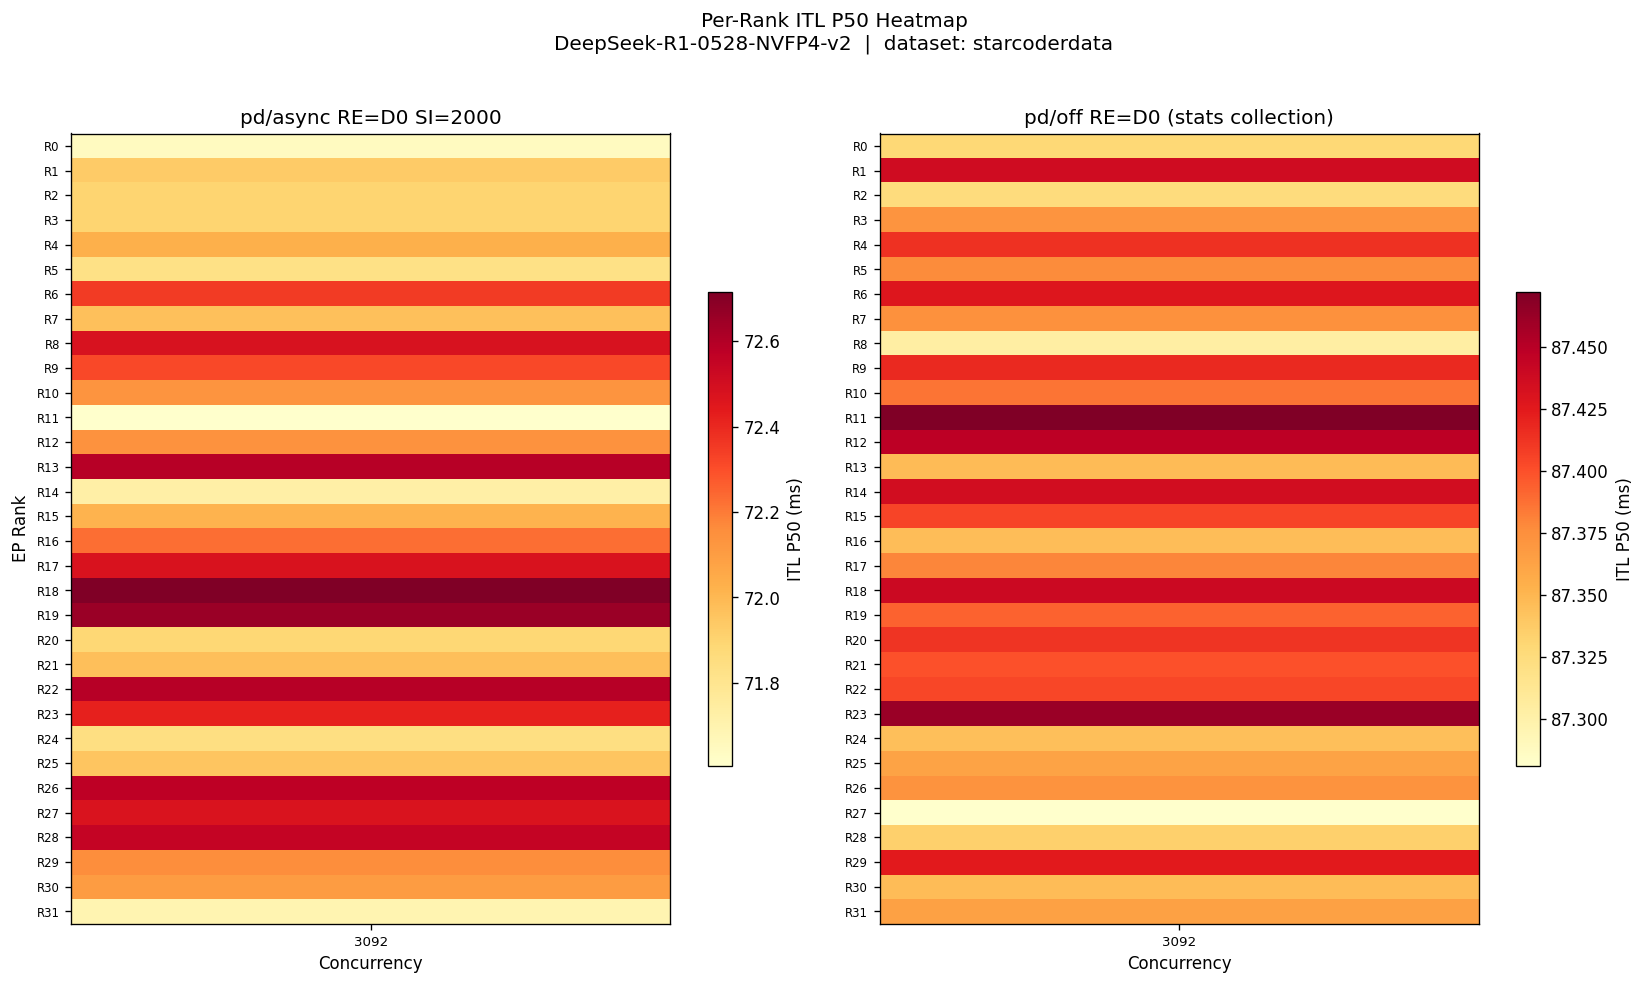

In [92]:
plot_per_rank_latency_heatmap(runs, metric="itl_p99", title="Per-Rank ITL P99 Heatmap (rank × stage)", stage=STAGE)
plt.show()
plot_per_rank_latency_heatmap(runs, metric="itl_p50", title="Per-Rank ITL P50 Heatmap", stage=STAGE)
plt.show()

In [ ]:
plot_per_rank_latency_heatmap(runs, metric="gen_tokens_per_sec", title="Per-Rank Gen Tokens/sec Heatmap")
plt.show()

## 6. Straggler & Overhead Decomposition

Correlate expert load with per-rank latency, decompose EPLB overhead
into forward-pass vs between-step components, and identify stragglers.

### 6a. Expert Load vs Per-Rank Latency

Scatter plot aligning per-rank expert token count with per-rank decode time.
If the rank with the most tokens has the highest latency, expert imbalance is causing stragglers.

Load vs latency for pd-async-eplb-sharegpt-v1


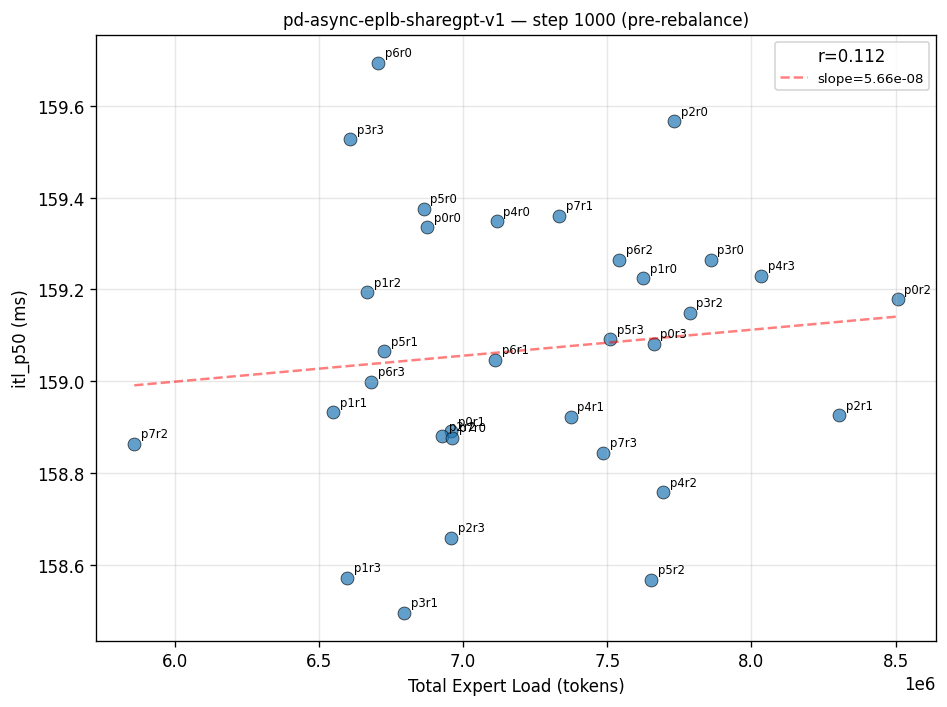

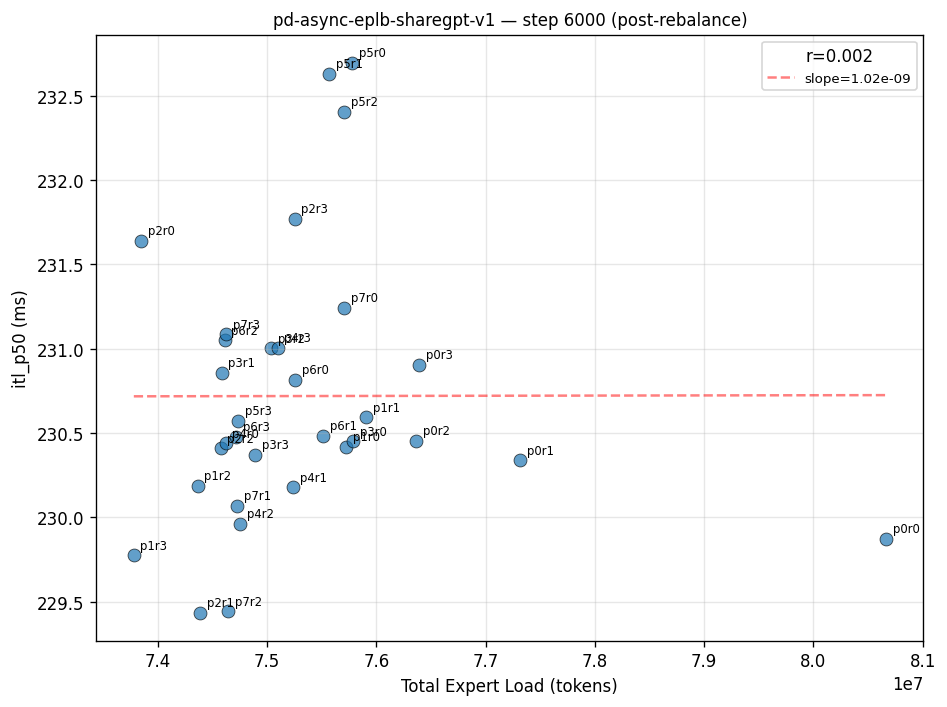


Load vs latency for pd-baseline-sharegpt-v1 (control — no rebalance)
No expert load data for role 'decode'


In [56]:
eplb_run_name = next((n for n in runs if "async-eplb" in n), None)
bl_v2_name = next((n for n in runs if "baseline" in n), None)
metric="itl_p50_range"
if eplb_run_name:
    eplb_run = runs[eplb_run_name]
    print(f"Load vs latency for {eplb_run_name}")
    plot_load_vs_latency(eplb_run, role="decode", step=1000, latency_metric=metric,
                         title=f"{eplb_run_name} — step 1000 (pre-rebalance)")
    plt.show()
    plot_load_vs_latency(eplb_run, role="decode", step=6000, latency_metric=metric,
                         title=f"{eplb_run_name} — step 6000 (post-rebalance)")
    plt.show()

if bl_v2_name:
    bl_v2_run = runs[bl_v2_name]
    print(f"\nLoad vs latency for {bl_v2_name} (control — no rebalance)")
    plot_load_vs_latency(bl_v2_run, role="decode", latency_metric=metric,
                         title=f"{bl_v2_name} — last step")
    plt.show()

### 6b. Per-Rank Decode Time Spread

Compare `decode_time_p50` spread (max/mean ratio) across runs at matched stages.
Lower spread in EPLB vs BL-v2 means rebalancing is helping reduce stragglers.

In [46]:
df_decode_spread = per_rank_stats_table(runs, metrics=["decode_time_p50", "decode_time_p99"])
if not df_decode_spread.empty:
    display(df_decode_spread.round(3))
else:
    print("No per-rank decode_time data found.")

mean       std  \
run                      concurrency metric                                 
agg/async RE=D32 SI=2000 256         decode_time_p50 138663.203 11910.079   
                                     decode_time_p99 458802.497  5926.600   
                         823         decode_time_p50 143440.433  7884.224   
                                     decode_time_p99 465669.203  1624.087   
                         1390        decode_time_p50 177521.263  4921.089   
                                     decode_time_p99 471379.477   649.742   
                         1957        decode_time_p50 213506.369  4756.055   
                                     decode_time_p99 474247.420   237.342   
                         2524        decode_time_p50 212900.082  3520.433   
                                     decode_time_p99 474257.295   158.949   
                         3092        decode_time_p50 228254.580  6641.174   
                                     decode_time_p99 474800.128   246.947   
agg/off                  256         decode_time_p50 136077.016 10676.343   
                                     decode_time_p99 450270.540 12033.955   
                         823         decode_time_p50 131480.923  7836.182   
                                     decode_time_p99 463452.514  3135.425   
                         1390        decode_time_p50 165642.763  6329.572   
                                     decode_time_p99 470243.097   871.410   
                         1957        decode_time_p50 183887.199  4549.458   
                                     decode_time_p99 472177.605   451.255   
                         2524        decode_time_p50 198004.864  4371.509   
                                     decode_time_p99 473373.861   327.060   
                         3092        decode_time_p50 214054.524  3608.492   
                                     decode_time_p99 474264.101   169.824   

                                                            min        max  \
run                      concurrency metric                                  
agg/async RE=D32 SI=2000 256         decode_time_p50 110689.655 160000.000   
                                     decode_time_p99 441200.000 468120.000   
                         823         decode_time_p50 126122.449 158108.108   
                                     decode_time_p99 462120.000 469600.000   
                         1390        decode_time_p50 168181.818 188289.474   
                                     decode_time_p99 469903.448 472441.121   
                         1957        decode_time_p50 205230.769 221485.714   
                                     decode_time_p99 473764.948 474578.947   
                         2524        decode_time_p50 203187.251 219282.511   
                                     decode_time_p99 473834.146 474562.759   
                         3092        decode_time_p50 214602.873 243151.434   
                                     decode_time_p99 474240.671 475261.859   
agg/off                  256         decode_time_p50 113051.948 157687.970   
                                     decode_time_p99 414700.000 464442.857   
                         823         decode_time_p50 113333.333 148085.106   
                                     decode_time_p99 455152.941 467810.526   
                         1390        decode_time_p50 150687.023 177000.000   
                                     decode_time_p99 468330.000 471962.791   
                         1957        decode_time_p50 173521.127 190961.538   
                                     decode_time_p99 471255.000 473149.515   
                         2524        decode_time_p50 188085.106 208235.294   
                                     decode_time_p99 472666.094 473978.648   
                         3092        decode_time_p50 208037.330 222636.800   
                                     decode_time_p99 473969.682 474657.851   

                           

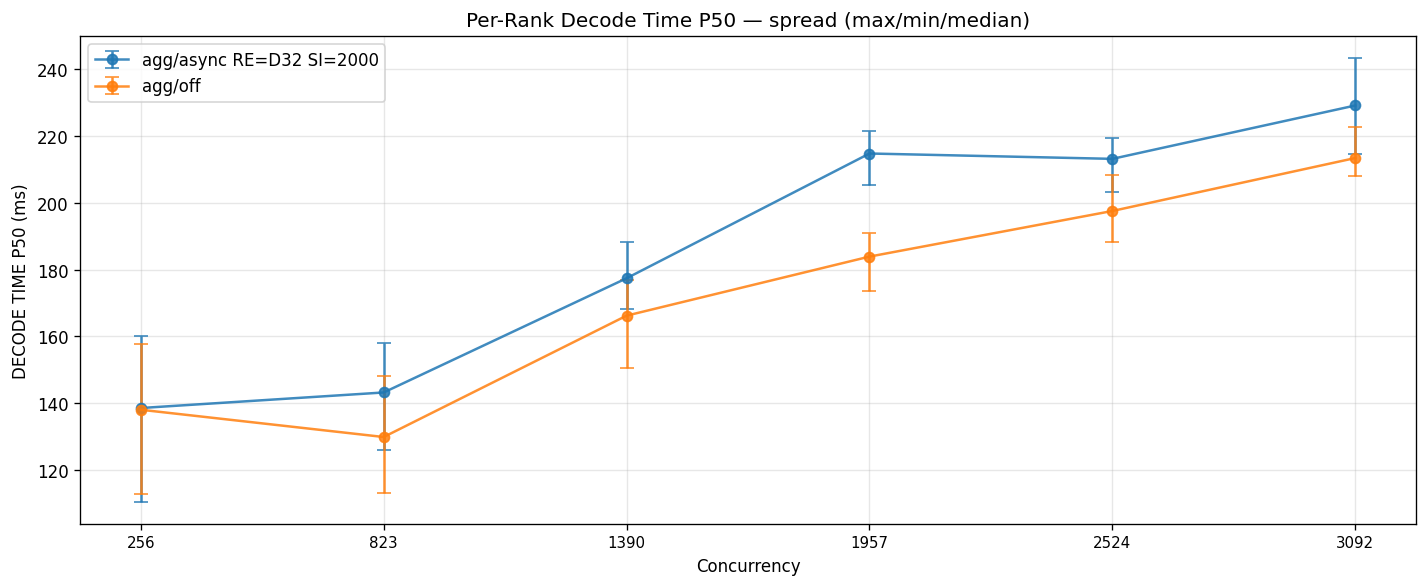

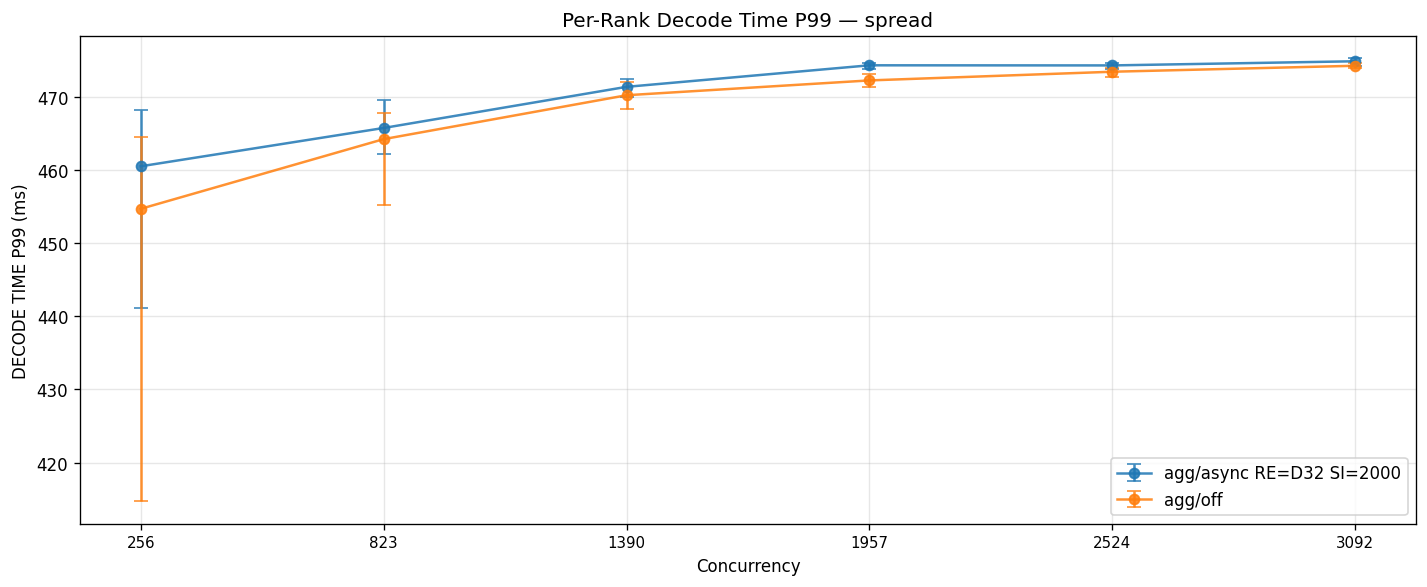

In [6]:
plot_per_rank_latency_spread(runs, metric="decode_time_p50",
                             title="Per-Rank Decode Time P50 — spread (max/min/median)")
plt.show()
plot_per_rank_latency_spread(runs, metric="decode_time_p99",
                             title="Per-Rank Decode Time P99 — spread")
plt.show()

### 6c. ITL - Decode Time Gap

The gap `itl_p50 - decode_time_p50` isolates time spent between decode steps:
scheduling, queuing, EPLB `check_and_step()`, detokenization.

- Constant gap across runs = EPLB overhead is inside the forward pass (memory, all2all)
- Growing gap in EPLB runs = per-iteration EPLB step logic is the culprit

In [7]:
df_gap = per_rank_stats_table(runs, metrics=["itl_p50", "decode_time_p50"])
if not df_gap.empty:
    # Pivot: index=(run, concurrency), columns=metric, values=mean
    gap_pivot = df_gap["mean"].unstack(level="metric")
    if "itl_p50" in gap_pivot.columns and "decode_time_p50" in gap_pivot.columns:
        gap_pivot["gap_ms"] = gap_pivot["itl_p50"] - gap_pivot["decode_time_p50"]
        display(gap_pivot.round(2))
    else:
        print(f"Available metrics after pivot: {list(gap_pivot.columns)}")
        display(gap_pivot.round(2))
else:
    print("No per-rank data available.")

metric                                decode_time_p50  itl_p50  gap_ms
run                      concurrency                                  
agg/async RE=D32 SI=2000 256                  138.660  179.400  40.740
                         823                  143.440  204.370  60.930
                         1390                 177.520  244.930  67.410
                         1957                 213.510  252.250  38.740
                         2524                 212.900  251.060  38.160
                         3092                 228.250  317.380  89.130
agg/off                  256                  136.080  174.670  38.600
                         823                  131.480  180.210  48.730
                         1390                 165.640  230.260  64.620
                         1957                 183.890  249.380  65.500
                         2524                 198.000  250.020  52.010
                         3092                 214.050  251.380  37.320

### 6d. Gen Tokens/sec Straggler Analysis

`gen_tokens_per_sec` spread is a proxy for straggler impact:
ranks that process fewer tokens per second are bottlenecked by imbalanced expert load
or EPLB overhead.

In [50]:
df_tps = per_rank_stats_table(runs, metrics=["gen_tokens_per_sec"])
if not df_tps.empty:
    display(df_tps.round(2))
else:
    print("No per-rank gen_tokens_per_sec data.")

mean    std  \
run                      concurrency metric                               
agg/async RE=D32 SI=2000 256         gen_tokens_per_sec  310.970 12.090   
                         823         gen_tokens_per_sec  659.240 13.490   
                         1390        gen_tokens_per_sec 1236.100 21.650   
                         1957        gen_tokens_per_sec 1554.050 21.240   
                         2524        gen_tokens_per_sec 2234.650 24.030   
                         3092        gen_tokens_per_sec 1987.970 27.880   
agg/off                  256         gen_tokens_per_sec  334.560 12.030   
                         823         gen_tokens_per_sec  694.660 16.950   
                         1390        gen_tokens_per_sec 1321.180 29.050   
                         1957        gen_tokens_per_sec 1881.370 33.800   
                         2524        gen_tokens_per_sec 2365.990 33.880   
                         3092        gen_tokens_per_sec 2514.730 23.900   

                                                             min      max  \
run                      concurrency metric                                 
agg/async RE=D32 SI=2000 256         gen_tokens_per_sec  287.550  333.500   
                         823         gen_tokens_per_sec  635.800  690.950   
                         1390        gen_tokens_per_sec 1194.790 1276.240   
                         1957        gen_tokens_per_sec 1508.680 1599.540   
                         2524        gen_tokens_per_sec 2175.030 2287.250   
                         3092        gen_tokens_per_sec 1926.880 2043.620   
agg/off                  256         gen_tokens_per_sec  310.520  360.310   
                         823         gen_tokens_per_sec  632.450  727.260   
                         1390        gen_tokens_per_sec 1251.300 1362.440   
                         1957        gen_tokens_per_sec 1816.910 1953.460   
                         2524        gen_tokens_per_sec 2297.990 2431.400   
                         3092        gen_tokens_per_sec 2474.330 2562.380   

                                                         max/mean  min_rank  \
run                      concurrency metric                                   
agg/async RE=D32 SI=2000 256         gen_tokens_per_sec     1.070        25   
                         823         gen_tokens_per_sec     1.050        23   
                         1390        gen_tokens_per_sec     1.030         7   
                         1957        gen_tokens_per_sec     1.030        20   
                         2524        gen_tokens_per_sec     1.020        20   
                         3092        gen_tokens_per_sec     1.030        11   
agg/off                  256         gen_tokens_per_sec     1.080        11   
                         823         gen_tokens_per_sec     1.050        23   
                         1390        gen_tokens_per_sec     1.030         6   
                         1957        gen_tokens_per_sec     1.040        28   
                         2524        gen_tokens_per_sec     1.030        24   
                         3092        gen_tokens_per_sec     1.020        10   

                                                         max_rank  
run                      concurrency metric                        
agg/async RE=D32 SI=2000 256         gen_tokens_per_sec        29  
                         823         gen_tokens_per_sec         1  
                         1390        gen_tokens_per_sec         5  
                         1957        gen_tokens_per_sec        21  
                         2524        gen_tokens_per_sec        13  
                         3092        gen_tokens_per_sec         5  
agg/off                  256         gen_tokens_per_sec         5  
                         823         gen_tokens_per_sec        10  
                         1390        gen_tokens_per_sec        14  
                         1957        gen_tokens_per_sec        29  
       

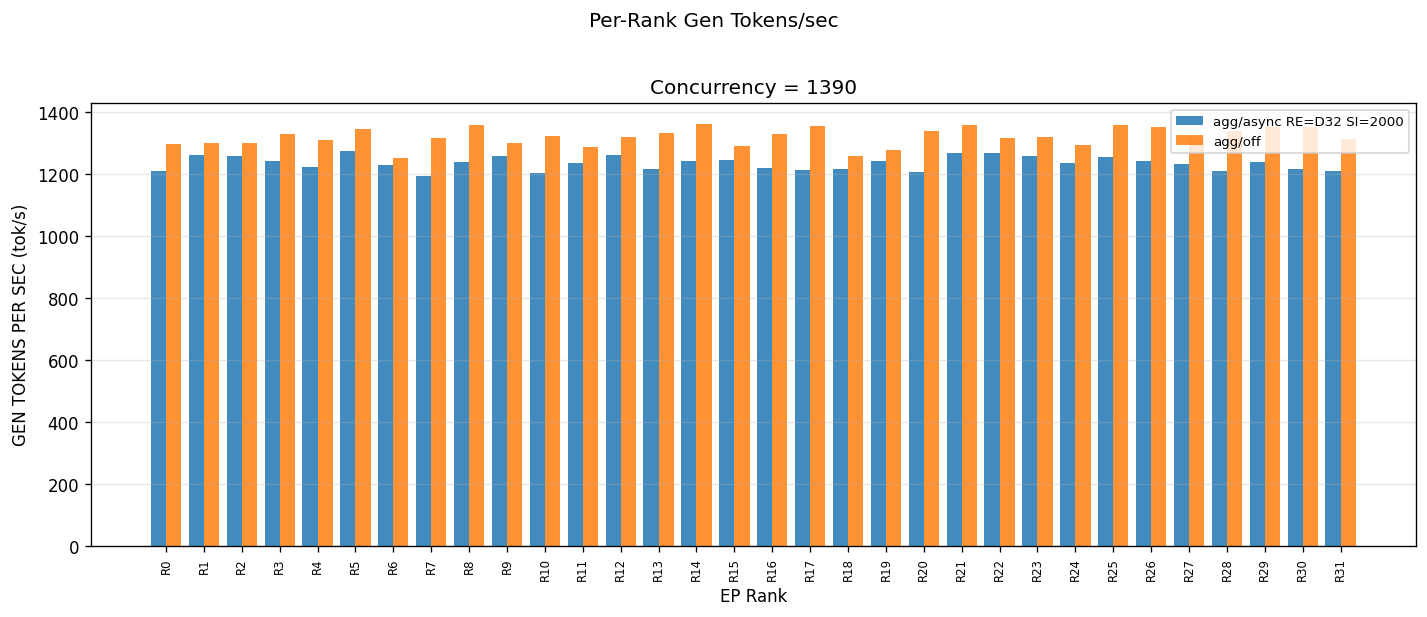

In [51]:
plot_per_rank_comparison(runs, metric="gen_tokens_per_sec", title="Per-Rank Gen Tokens/sec", stage=STAGE)
plt.show()

In [ ]:
plot_per_rank_latency_heatmap(runs, metric="gen_tokens_per_sec",
                              title="Per-Rank Gen Tokens/sec Heatmap (rank × stage)")
plt.show()

## 7. Latency Comparison

Detailed stage-by-stage latency breakdown for reference.

### 7a. TTFT and ITL per concurrency stage

In [ ]:
plot_latency_comparison(runs, metric="ttft_p50", title="TTFT P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="ttft_p99", title="TTFT P99 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p50", title="ITL P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p99", title="ITL P99 by Concurrency Stage")
plt.show()

### 7b. Latency time series

In [ ]:
plot_latency_timeseries(runs, "ttft_p99_range", "TTFT P99 Over Time")
plt.show()
plot_latency_timeseries(runs, "itl_p99_range", "ITL P99 Over Time")
plt.show()

### 7c. Phase time breakdown

Where is latency spent? Prefill compute, decode compute, or queue.

In [ ]:
plot_phase_time_comparison(runs, percentile="p99")
plt.show()
plot_phase_time_comparison(runs, percentile="p50")
plt.show()
plot_phase_time_timeseries(runs)
plt.show()

## 8. Parameter Sweep Analysis

Use these cells when comparing `num_redundant_experts` or `step_interval` sweeps.

In [ ]:
def filter_runs_by_prefix(runs: dict, prefix: str) -> dict:
    """Filter runs whose name starts with a prefix."""
    return {k: v for k, v in runs.items() if k.startswith(prefix)}

nre_runs = filter_runs_by_prefix(runs, "nre-")
if nre_runs:
    print(f"num_redundant_experts sweep: {list(nre_runs.keys())}")
    plot_latency_comparison(nre_runs, title="Latency vs num_redundant_experts")
    plt.show()
    plot_throughput_comparison(nre_runs, title="Throughput vs num_redundant_experts")
    plt.show()
    plot_kv_cache_usage(nre_runs, title="KV Cache vs num_redundant_experts")
    plt.show()
    plot_balancedness_comparison(nre_runs, title="Balancedness vs num_redundant_experts")
    plt.show()
else:
    print("No nre-* runs found.")

In [ ]:
si_runs = filter_runs_by_prefix(runs, "si-")
if si_runs:
    print(f"step_interval sweep: {list(si_runs.keys())}")
    plot_latency_comparison(si_runs, title="Latency vs step_interval")
    plt.show()
    plot_throughput_comparison(si_runs, title="Throughput vs step_interval")
    plt.show()
    plot_balancedness_comparison(si_runs, title="Balancedness vs step_interval")
    plt.show()
else:
    print("No si-* runs found.")

## 9. Custom Queries

Scratch cells for ad-hoc analysis.

In [ ]:
# Compare two specific runs side by side
# run_a = load_run("run-name-a", results_dir)
# run_b = load_run("run-name-b", results_dir)
# subset = {"a": run_a, "b": run_b}
# plot_latency_comparison(subset)
# plot_throughput_comparison(subset)

In [ ]:
# Access raw Prometheus range data for custom plotting
# run = list(runs.values())[0]
# if run.prometheus:
#     df = run.prometheus.range_series("gen_tokens_per_sec_range")
#     if df is not None:
#         df.plot(x="time_min", y="value", title=f"{run.name} throughput")
#         plt.show()